### Individual neurofeedback performance analyses

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.manifold import MDS
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

In [ ]:
PATHs = {
    "data": "../data",
    "result": "../results"
    }

In [3]:
from utils import set_log
logger = set_log("individual_NF.log", os.path.join(PATHs["result"], "logs"), stream_handler = False)

c:\Users\xuwang\Anaconda3\envs\py36\lib\site-packages\nilearn\__init__.py:69: FutureWarning: Python 3.6 support is deprecated and will be removed in release 0.10 of Nilearn. Consider switching to Python 3.8 or 3.9.
  _python_deprecation_warnings()


In [4]:
CONDITIONs = ["Anger", "Enthusiasm", "Joyfulrelaxation", "Sadness"]

In [ ]:
SUB_with_questionnaire = ["S#####"]

SUB_without_NF = ["S#####"]

In [ ]:
control_ratings = {
    "Joyfulrelaxation": {
        "S#####": "Y, 4"
    },
    "Joyfulrelaxation2": {
        "S#####": "Y, 4"
    },
    "Sadness": {
        "S#####": "Y, 4"
    }
}

#### 1. Perceived control ratings analysis

In [7]:
def load_behaviour_data(path, run_idx):
    behaviour_data = pd.read_csv(path)
    behaviour_data["sub_id"] = behaviour_data["ID"].str.upper()
    # Extract control data for each participant in order
    control_data = behaviour_data[behaviour_data["sub_id"].isin(SUB_with_questionnaire)].sort_values(
        by = "sub_id", key = lambda x: pd.Categorical(x, categories = SUB_with_questionnaire, ordered = True)
    )[f"control_{run_idx}"]
    return control_data

#### 2. Individual neurofeedback success score 

In [8]:
def load_performance_data(path, run_idx, metric):
    performance_data = pd.read_csv(path)
    performance_data["sub_id"] = performance_data["sub_id"].str.upper()
    performance_data = performance_data[performance_data["sub_id"].isin(SUB_with_questionnaire)]
    performance_data = performance_data[performance_data["run"] == f"Run {run_idx}"]
    metric_data = performance_data.sort_values(
        by = "sub_id", key = lambda x: pd.Categorical(x, categories = SUB_with_questionnaire, ordered = True)
    )[f"{metric}_slope"]
    return metric_data

In [9]:
def individual_feedback_analysis(target_cond_idx, slope_metric = "linregress"):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", "group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    group_df = group_df[group_df["time"] > 2]
    results = []
    all_results = []
    for pid, group in group_df.groupby("sub_id"):
        for run_desc in ["Run 1", "Run 2"]:
            if target_cond_idx == 3 and run_desc == "Run 2": continue
            run_result = {"sub_id": pid, "run": run_desc}
            for metric in [f"cond{target_cond_idx}_correlation", "angular_distance", "intensity"]:
                run_group = group[group["run"] == run_desc]
                if slope_metric == "linregress": slope, _, _, p_value, _ = stats.linregress(run_group["time"], run_group[metric])
                elif slope_metric == "spearman": slope, p_value = stats.spearmanr(run_group["time"], run_group[metric])
                else: raise ValueError(f"Invalid slope metric: {slope_metric}")
                run_result.update({
                    f"{metric}_slope": np.nan_to_num(slope),
                    f"{metric}_p_value": p_value,
                })
            all_results.append(run_result)
    all_results_df = pd.DataFrame(all_results)
    for metric in [f"cond{target_cond_idx}_correlation", "angular_distance", "intensity"]:
        all_results_df[f"{metric}_p_value"] = multipletests(all_results_df[f"{metric}_p_value"], alpha = 0.05, method = 'fdr_bh')[1]
    for pid, group in group_df.groupby("sub_id"):
        for run_desc in ["Run 1", "Run 2"]:
            if target_cond_idx == 3 and run_desc == "Run 2": continue
            run_result = {"sub_id": pid, "run": run_desc,}
            for metric in [f"cond{target_cond_idx}_correlation", "angular_distance", "intensity"]:
                slope = all_results_df.loc[(all_results_df["sub_id"] == pid) & (all_results_df["run"] == run_desc), f"{metric}_slope"].values[0]
                p_value = all_results_df.loc[(all_results_df["sub_id"] == pid) & (all_results_df["run"] == run_desc), f"{metric}_p_value"].values[0]
                success = (slope > 0 and p_value < 0.05) if metric != "angular_distance" else (slope < 0 and p_value < 0.05)
                run_result.update({
                    f"{metric}_slope": "%.3f"%np.nan_to_num(slope),
                    f"{metric}_p_value": "%.3f"%p_value if p_value > 0.001 else "< 0.001",
                    f"{metric}_success": "Y" if success else "N",
                })
            results.append(run_result)
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(PATHs["result"], "feedback", f"individual_performance_{CONDITIONs[target_cond_idx]}_{slope_metric}_fdr.csv"), index = False)

In [10]:
# joyful relaxation
individual_feedback_analysis(2)

In [11]:
# sadness
individual_feedback_analysis(3)

#### 3. Correlation between self-ratings and success scores

In [12]:
def scatter_plot(target_cond_idx, performance_data, behaviour_data, ax, run_idx, metric):
    colors = {f"cond{target_cond_idx}_correlation": "navy", "angular_distance": "forestgreen", "intensity": "darkorange"}
    sub_titles = {f"cond{target_cond_idx}_correlation": "Pearson's correlation", "angular_distance": "Angular distance", "intensity": "Intensity level"}
    ax.scatter(performance_data, behaviour_data, s = 50, c = colors[metric])
    ax.tick_params(axis = 'both', which = 'major', labelsize = 16)
    if run_idx == 2 or target_cond_idx == 3:
        ax.set_xlabel("performance slopes", fontsize = 18)
    if metric == f"cond{target_cond_idx}_correlation":
        ax.set_ylabel("perceived control ratings", fontsize = 18)
    if target_cond_idx == 3:
        ax.set_title(f"{sub_titles[metric]}", fontsize = 18)
    else:
        ax.set_title(f"Run {run_idx} ({sub_titles[metric]})", fontsize = 18)
    # Test for normality first
    _, p_norm1 = stats.shapiro(performance_data)
    _, p_norm2 = stats.shapiro(behaviour_data)
    # Use Pearson if both normal, otherwise Spearman
    if p_norm1 > 0.05 and p_norm2 > 0.05:
        corr_metric = "Pearson"
        coef, p_value = stats.pearsonr(performance_data, behaviour_data)
    else:
        corr_metric = "Spearman"
        coef, p_value = stats.spearmanr(performance_data, behaviour_data)
    if target_cond_idx == 2: p_value = p_value * 2                   # bonferonni correction (n = 2)
    z = np.polyfit(performance_data, behaviour_data, 1)
    p = np.poly1d(z)
    x_range = np.linspace(min(performance_data), max(performance_data), 100)
    ax.plot(x_range, p(x_range), color = colors[metric], alpha = 0.8, linewidth = 3)
    if metric == f"cond{target_cond_idx}_correlation":
        ax.text(0.6, 0.3, f" r = {coef:.2f}\n p = {p_value:.3f}", fontsize = 16,
                transform = ax.transAxes, verticalalignment = "top", horizontalalignment = "left")
    elif metric == "angular_distance":
        if run_idx == 1:
            ax.text(0.6, 0.9, f" r = {coef:.2f}\n p = {p_value:.3f}", fontsize = 16,
                    transform = ax.transAxes, verticalalignment = "top", horizontalalignment = "left")
        elif run_idx == 2:
            ax.text(0.1, 0.3, f" r = {coef:.2f}\n p = {p_value:.3f}", fontsize = 16,
                    transform = ax.transAxes, verticalalignment = "top", horizontalalignment = "left")
    elif metric == "intensity":
        ax.text(0.6, 0.3, f" r = {coef:.2f}\n p = {p_value:.3f}", fontsize = 16,
                transform = ax.transAxes, verticalalignment = "top", horizontalalignment = "left")


In [13]:
def correlation_analysis(target_cond_idx, performance_datapath, behaviour_datapath):
    total_runs = 2 if target_cond_idx == 2 else 1
    fig, axes = plt.subplots(total_runs, 3, figsize = (12, 4*total_runs))
    axes = axes.flatten()
    runs_data = []
    for run_idx in range(1, total_runs+1):
        behaviour_data = load_behaviour_data(behaviour_datapath, run_idx)
        print(f"Run {run_idx}: mean={behaviour_data.mean()}, std={behaviour_data.std()}")
        runs_data.append(behaviour_data)
        for metric_idx, metric in enumerate([f"cond{target_cond_idx}_correlation", "angular_distance", "intensity"]):
            performance_data = load_performance_data(performance_datapath, run_idx, metric)
            scatter_plot(target_cond_idx, performance_data, behaviour_data, axes[(run_idx-1)*3+metric_idx], run_idx, metric)
    if total_runs == 2:
        t_stat, p_value = stats.ttest_rel(runs_data[1], runs_data[0])
        print(f"Paired t-test: t-stat={t_stat:.2f}, p-value={p_value:.3f}, df={len(runs_data[0])-1}")
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", f"subj-obj_correlation_{CONDITIONs[target_cond_idx]}.png"))
    # plt.close()

Run 1: mean=4.636363636363637, std=1.6196841122196093
Run 2: mean=5.454545454545454, std=2.283007054768165
Paired t-test: t-stat=1.80, p-value=0.086, df=21


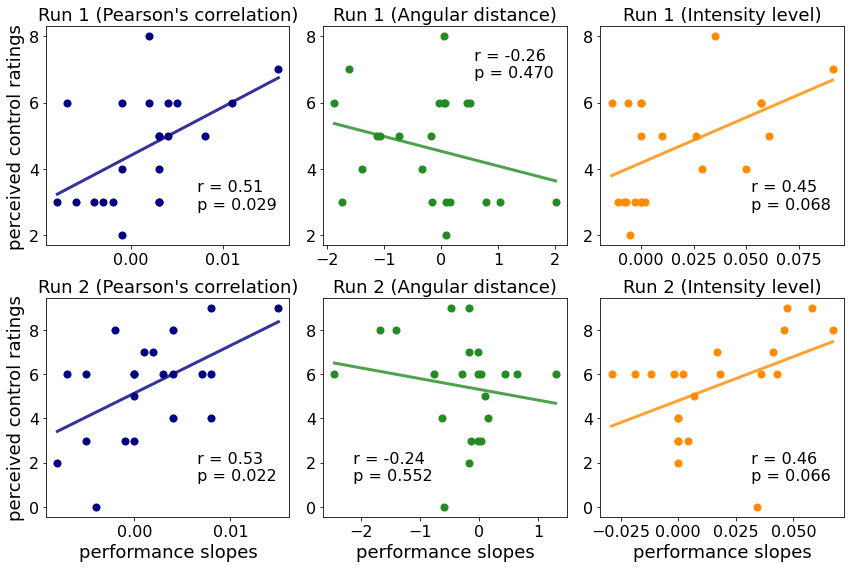

In [14]:
performance_datapath = os.path.join(PATHs["result"], "feedback", f"individual_performance_{CONDITIONs[2]}_linregress_fdr.csv")
rating_datapath = os.path.join(PATHs["data"], "behavior", f"self_ratings_{CONDITIONs[2]}.csv")
correlation_analysis(2, performance_datapath, rating_datapath)

Run 1: mean=4.7272727272727275, std=2.5725827135743993


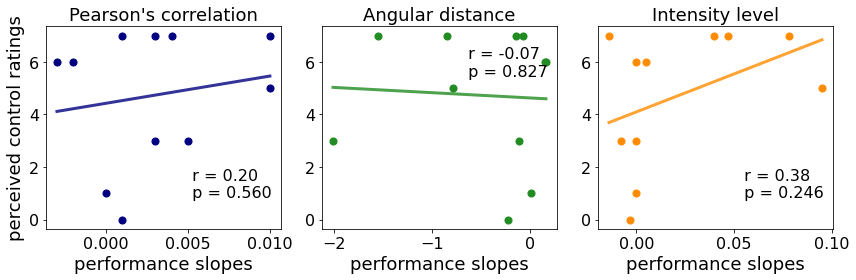

In [15]:
performance_datapath = os.path.join(PATHs["result"], "feedback", f"individual_performance_{CONDITIONs[3]}_linregress_fdr.csv")
rating_datapath = os.path.join(PATHs["data"], "behavior", f"self_ratings_{CONDITIONs[3]}.csv")
correlation_analysis(3, performance_datapath, rating_datapath)

#### 4. Individual modulation trajectory visualization

In [16]:
def compute_dist(X, Y = None):
    if Y is None: Y = X
    N = X.shape[0]
    M = Y.shape[0]
    dist_matrix = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
                r, _ = stats.pearsonr(X[i], Y[j])
                dist = 1 - r
                dist_matrix[i, j] = dist
    return dist_matrix

In [17]:
def mds_visualize_distribution(base_patterns, all_rt_patterns, ax, sub_id, sub_title):
    dist_matrix = compute_dist(base_patterns)
    # Fit MDS on the 4 base patterns
    mds = MDS(n_components = 2, dissimilarity = 'precomputed', random_state = 42)
    base_2d = mds.fit_transform(dist_matrix)  # shape: (4, 2)
    # Optional emotion names
    emotion_labels = ["Anger", "Enthusiasm", "Joyfulrelaxation", "Sadness"]
    base_colors = ["#2B91BF", "sienna" , "#851A79", "#67976D"]
    rt_labels = ["Joyfulrelaxation", "Joyfulrelaxation2", "Sadness"]
    rt_colors = [
        ['#c28cbc', '#b676af', '#aa5fa1', '#9d4894', '#913186', '#851a79'],
        ['#c28cbc', '#b676af', '#aa5fa1', '#9d4894', '#913186', '#851a79'],
        ['#b3cbb6', '#a4c1a7', '#95b699', '#85ac8a', '#76a17c', '#67976d']
    ]
    rt_shapes = ["o", "^", "o"] # square, triangle, circle
    # Plot
    for rt_idx, rt_patterns in enumerate(all_rt_patterns):
        if rt_patterns is None: continue
        rt_to_base_dist = compute_dist(rt_patterns, base_patterns)  # shape: (60, 4)
        # Now estimate 2D position by least-squares triangulation
        # Assume: each real-time vector lies approximately near a combination of base vectors
        # We'll treat this as solving: rt_dist ≈ ||x - base_2d||, approximated linearly
        # Simplified approach: use inverse-distance weighting as soft projection
        weights = 1 / (rt_to_base_dist + 1e-8)
        # Weighted average of base_2d positions
        rt_2d = weights @ base_2d  # shape: (60, 2)
        ax.scatter(x = rt_2d[:10, 0], y = rt_2d[:10, 1], color = rt_colors[rt_idx][0], s = 30, marker = rt_shapes[rt_idx])
        ax.scatter(x = rt_2d[10:20, 0], y = rt_2d[10:20, 1], color = rt_colors[rt_idx][1], s = 30, marker = rt_shapes[rt_idx])
        ax.scatter(x = rt_2d[20:30, 0], y = rt_2d[20:30, 1], color = rt_colors[rt_idx][2], s = 30, marker = rt_shapes[rt_idx])
        ax.scatter(x = rt_2d[30:40, 0], y = rt_2d[30:40, 1], color = rt_colors[rt_idx][3], s = 30, marker = rt_shapes[rt_idx])
        ax.scatter(x = rt_2d[40:50, 0], y = rt_2d[40:50, 1], color = rt_colors[rt_idx][4], s = 30, marker = rt_shapes[rt_idx])
        ax.scatter(x = rt_2d[50:, 0], y = rt_2d[50:, 1], color = rt_colors[rt_idx][5], s = 30, marker = rt_shapes[rt_idx], label = 'NF-'+rt_labels[rt_idx])
    # Plot base points
    for i, label in enumerate(emotion_labels):
        ax.scatter(base_2d[i, 0], base_2d[i, 1], s = 120, label = label, color = base_colors[i], marker = "o")
    scores = [control_ratings[rt_labels[rt_idx]].get(sub_id, '-') for rt_idx in range(len(rt_labels))]
    ax.set_title(f"{sub_title} [({scores[0]}); ({scores[1]}); ({scores[2]})]", fontsize = 15)
    ax.tick_params(axis = 'both', labelsize = 15)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.grid(True)
    return by_label

In [ ]:
def run_for_all_subs(ax_id, save_path):
    all_subs = glob.glob(os.path.join(PATHs["data"], "realtime", "20*S*S*"))
    fig, axes = plt.subplots(6, 4, figsize = (12, 16))
    axes = axes.flatten()
    all_subs = sorted(all_subs)
    sub_id_list = ["S14", "S17", "S25", "S08", "S12", "S16", "S05",\
        "S07", "S20", "S26", "S27", "S09", "S19", "S23", "S04", "S06",\
        "S10", "S15", "S18", "S22", "S11", "S21", "S02", "S03"
    ]
    for sub_idx, tgt_id in enumerate(sub_id_list):
        sub = all_subs[int(tgt_id.replace("S", "")) - 1]
        base_datapath = os.path.join(sub, "TBV_Files_Template_10blocks/rtRSA_output/sel_base_patterns.tvals")
        rt1_datapath = os.path.join(sub, "TBV_Files_Template_10blocks/TargetFolder/Joyfulrelaxation_NF/all_rt_patterns.txt")
        rt2_datapath = os.path.join(sub, "TBV_Files_Template_10blocks/TargetFolder/Joyfulrelaxation_NF2/all_rt_patterns.txt")
        rt3_datapath = os.path.join(sub, "TBV_Files_Template_10blocks/TargetFolder/Sadness_NF/all_rt_patterns.txt")
        base_patterns = np.loadtxt(base_datapath).T
        rt1_patterns = np.loadtxt(rt1_datapath).T if os.path.exists(rt1_datapath) else None
        rt2_patterns = np.loadtxt(rt2_datapath).T if os.path.exists(rt2_datapath) else None
        rt3_patterns = np.loadtxt(rt3_datapath).T if os.path.exists(rt3_datapath) else None
        sub_id = sub.split(".")[-1]
        mds_visualize_distribution(base_patterns, [rt1_patterns, rt2_patterns, rt3_patterns], axes[ax_id[sub_idx]], sub_id, tgt_id)
    for idx in range(len(axes)):
        if idx not in ax_id: axes[idx].axis("off")
    axes[20].set_visible(False)
    plt.tight_layout()
    plt.show()
    # plt.savefig(save_path, dpi = 300)
    # plt.close()

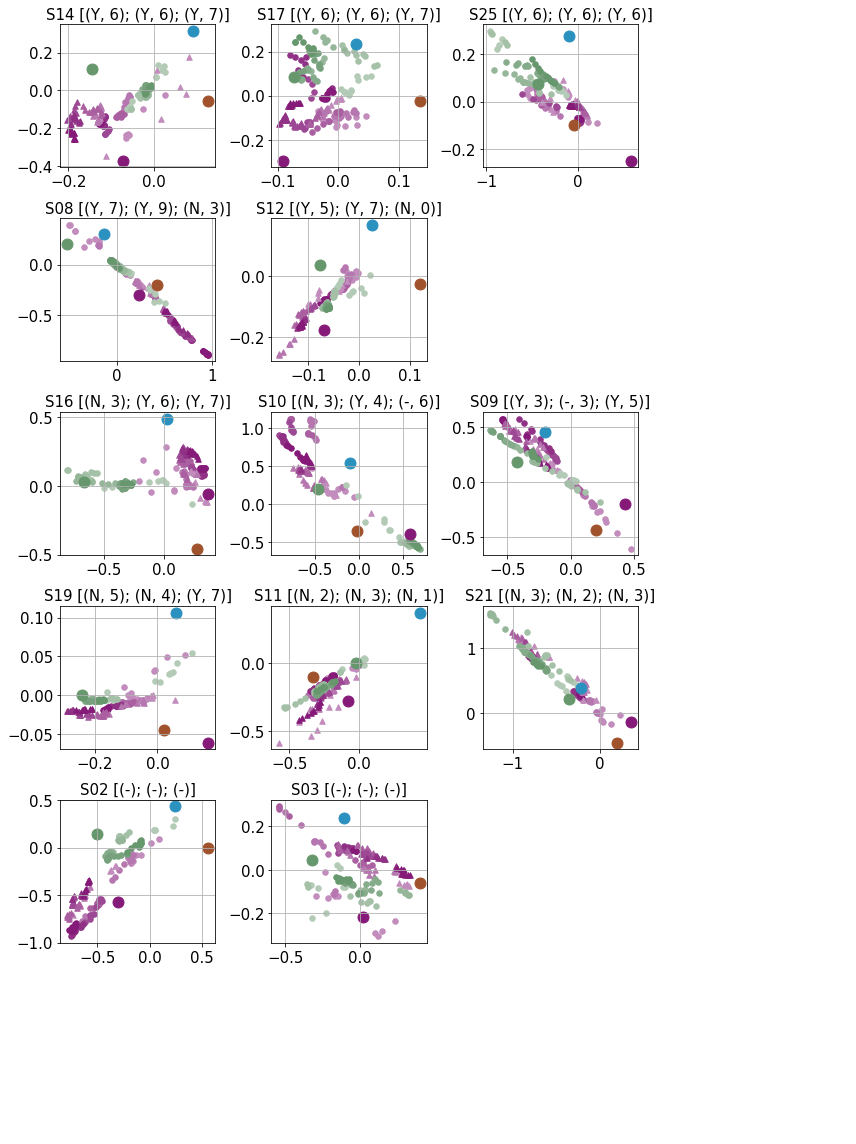

In [19]:
# For participants with both joyful relaxation and sadness
save_path = os.path.join(PATHs["result"], "figures", "mds_visualization_with-sadness.png")
ax_id = [0, 1, 2, 4, 5, 8, 20, 20, 20, 20, 20, 10, 12, 20, 20, 20, 9, 20, 20, 20, 13, 14, 16, 17]
run_for_all_subs(ax_id, save_path)

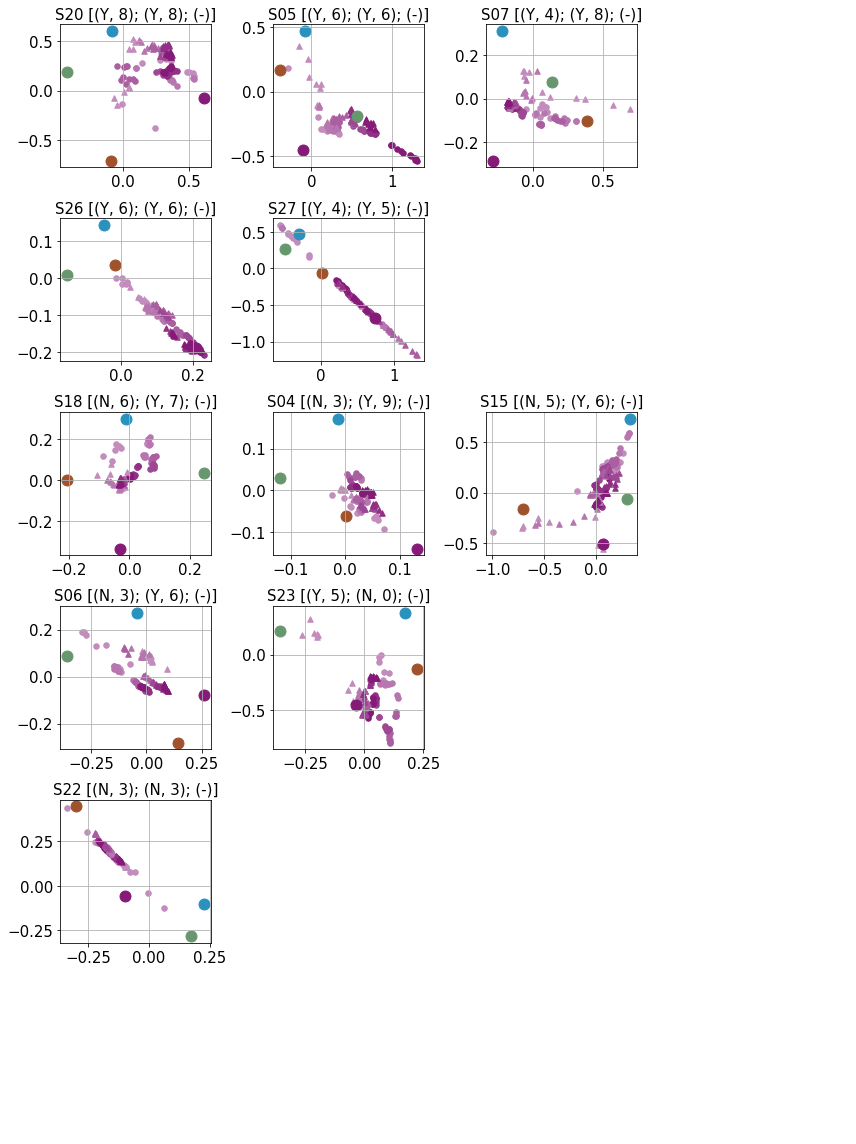

In [20]:
# For participants with only joyful relaxation
save_path = os.path.join(PATHs["result"], "figures", "mds_visualization_no-sadenss.png")
ax_id = [20, 20, 20, 20, 20, 20, 1, 2, 0, 4, 5, 20, 20, 13, 9, 12, 20, 10, 8, 16, 20, 20, 20, 20]
run_for_all_subs(ax_id, save_path)

#### 5. Strategies categorization

In [21]:
def strategy_analysis(path):
    behaviour_data = pd.read_csv(path)
    behaviour_data["sub_id"] = behaviour_data["ID"].str.upper()
    behaviour_data = behaviour_data[behaviour_data["sub_id"].isin(SUB_with_questionnaire)]
    fig, axes = plt.subplots(2, 4, figsize = (15, 8))
    axes = axes.flatten()
    sub_titles = ["Localizer (Joyfulrelaxation)", "Localizer (Sadness)", "Localizer (Enthusiasm)", "Localizer (Anger)", 
                  "NF Run 1 (Joyfulrelaxation)", "NF Run 2 (Joyfulrelaxation)", "NF Run 3 (Sadness)"]
    categories = {"AR": "Autobiographical Recall", "BS": "Body-related Sensations", "IS": "Imagined Situations",
                  "NI": "Nature-related Imagery", "SI": "Social/Interpersonal Imagery"}
    # Create a figure-level legend by storing wedges and labels from first subplot
    # Create a color map for consistent colors across subplots
    all_strategies = []
    for desc in ["loc1", "loc2", "loc3", "loc4", "nf1", "nf2", "nf3"]:
        col_name = f"strategy_{desc}"
        strategy_data = behaviour_data[col_name].dropna()
        strategies = [s.strip() for d in strategy_data for s in d.split('+')]
        all_strategies.extend(strategies)
    unique_strategies = list(set(all_strategies))
    colors = ['#66c2a5', '#8da0cb', '#fc8d62'] 
    color_map = dict(zip(unique_strategies, colors))
    all_wedges = []
    all_labels = []
    for idx, desc in enumerate(["loc1", "loc2", "loc3", "loc4", "nf1", "nf2", "nf3"]):
        col_name = f"strategy_{desc}"
        strategy_data = behaviour_data[col_name].dropna()
        # Split each strategy string into a list of individual strategies
        strategy_data = [d.split('+') for d in strategy_data]
        # Need to flatten the list first and then count occurrences
        strategy_data = [strategy.strip() for strategies in strategy_data for strategy in strategies]
        strategy_counts = pd.Series(strategy_data).value_counts()
        # Map strategies to their assigned colors
        strategy_colors = [color_map[s] for s in strategy_counts.index]
        wedges, _, _ = axes[idx].pie(strategy_counts.values, labels = None, colors = strategy_colors, 
                                    autopct = '%1.1f%%', textprops = {'fontsize': 16})
        axes[idx].set_title(f'{sub_titles[idx]}', fontsize = 17)
        # Store wedges and labels from first subplot to use in legend
        if idx == 2:
            all_wedges = wedges
            all_labels = [categories[s] for s in strategy_counts.index]
    # Add a single legend for the entire figure
    axes[-1].axis('off')
    plt.legend(all_wedges, all_labels, fontsize = 16, bbox_to_anchor = (1.2, 1.0))
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", "strategy_analysis.png"))
    # plt.close()

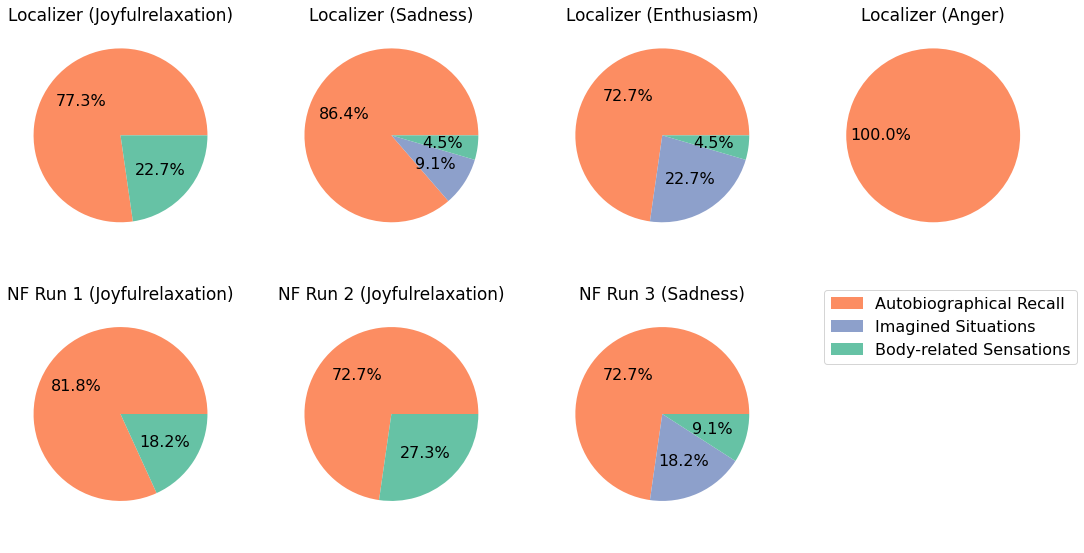

In [22]:
strategy_datapath = os.path.join(PATHs["data"], "behavior", "strategies.csv")
strategy_analysis(strategy_datapath)